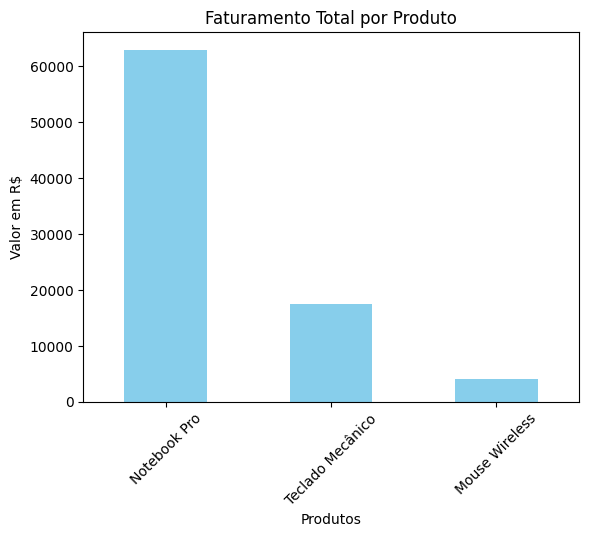

--- Resumo da Operação ---
Faturamento Total: R$ 84,450.00
Ticket Médio por Venda: R$ 16,890.00

--- Performance por Produto ---
                  Quantidade  Faturamento_Total
Produto                                        
Notebook Pro              15            63000.0
Teclado Mecânico           8            17400.0
Mouse Wireless            27             4050.0

[Status] Processamento concluído e relatório CSV gerado.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # Adição importante para os gráficos

# 1. Carga e Estruturação da Base de Dados
dados_vendas = {
    'Data': ['2026-05-01', '2026-05-01', '2026-05-02', '2026-05-02', '2026-05-03'],
    'Produto': ['Notebook Pro', 'Mouse Wireless', 'Notebook Pro', 'Teclado Mecânico', 'Mouse Wireless'],
    'Quantidade': [5, 12, np.nan, 8, 15],
    'Preco_Unitario': [4200.00, 150.00, 4200.00, np.nan, 150.00]
}

df = pd.DataFrame(dados_vendas)

# 2. Tratamento de Dados (Data Cleaning)
# Preenchimento de nulos com média e mediana para manter a integridade dos cálculos
df['Quantidade'] = df['Quantidade'].fillna(df['Quantidade'].mean()).astype(int)
df['Preco_Unitario'] = df['Preco_Unitario'].fillna(df['Preco_Unitario'].median())

# 3. Processamento de Indicadores
df['Faturamento_Total'] = df['Quantidade'] * df['Preco_Unitario']

# Agrupamento para performance por produto
performance_produtos = df.groupby('Produto').agg({
    'Quantidade': 'sum',
    'Faturamento_Total': 'sum'
}).sort_values(by='Faturamento_Total', ascending=False)

# 4. Geração de Gráfico (Visualização de Dados)
# Isso demonstra que você sabe transformar dados em informação visual
performance_produtos['Faturamento_Total'].plot(kind='bar', color='skyblue')
plt.title('Faturamento Total por Produto')
plt.xlabel('Produtos')
plt.ylabel('Valor em R$')
plt.xticks(rotation=45)
plt.show()

# 5. Geração de Insights e Exportação
faturamento_consolidado = df['Faturamento_Total'].sum()
ticket_medio = df['Faturamento_Total'].mean()

print("--- Resumo da Operação ---")
print(f"Faturamento Total: R$ {faturamento_consolidado:,.2f}")
print(f"Ticket Médio por Venda: R$ {ticket_medio:,.2f}")
print("\n--- Performance por Produto ---")
print(performance_produtos)

# Exportação do relatório final
df.to_csv('relatorio_vendas_processado.csv', index=False)
print("\n[Status] Processamento concluído e relatório CSV gerado.")